# Forecasting Final Cost and Margin with Machine Learning
**Author:** Atul Iwale · **Project 1** of the AEC Fieldwork portfolio (machine-learning upgrade)

**Business question:** part-way through a project, what will it finally cost, what margin will we actually make, and how much will we spend next quarter?

The first version of this project flagged months where CPI or SPI fell below 0.90. That tells you a project *has* underperformed. A commercial manager needs a forward view: the **Estimate at Completion (EAC)**. The standard formula, EAC = AC + (BAC − EV) / CPI, assumes the rest of the job will perform like the past. This notebook tests whether machine learning, trained on 239 completed projects, forecasts final cost more accurately and earlier, and gives an honest range around it.

**Contents**
1. Load and audit the data
2. Margin fade: tender margin vs final margin
3. Why the CPI formula under-forecasts
4. Monthly snapshots and features (leakage-safe)
5. Train / validation / test split by time
6. Baselines: earned-value formulas
7. Models: Ridge, Random Forest, XGBoost, Neural Network (MLP), LSTM
8. Accuracy by stage of completion
9. Forecast ranges (P10–P90)
10. Explain the model (SHAP)
11. Next-quarter spend: naive, plan × CPI, Holt's exponential smoothing, XGBoost
12. Live forecast for the projects still in progress
13. Export for the web app

In [1]:
import warnings, json, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import xgboost as xgb, shap, tensorflow as tf
tf.keras.utils.set_random_seed(7); tf.config.experimental.enable_op_determinism()
pd.set_option('display.width', 170); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
DATA = '../data/01_Cost_Margin_Forecasting_v2.xlsx'
cr = lambda v: v / 1e7   # rupees -> crore

## 1. Load and audit the data

In [2]:
import numpy as np, pandas as pd
CATS = ['Labor', 'Material', 'Equipment', 'Subcontract', 'Overhead']

def load(path):
    x = pd.read_excel(path, sheet_name=None)
    reg, F, idx = x['project_register'].copy(), x['fact_monthly_cost'].copy(), x['material_price_index'].copy()
    for c in ('planned_start', 'planned_finish'): reg[c] = pd.to_datetime(reg[c])
    F['period_month'] = pd.to_datetime(F.period_month); idx['month'] = pd.to_datetime(idx.month)
    return x, reg, F, idx

def snapshots(reg, F, idx, lo=0.05, hi=0.99):
    """one row per project per month-end, using only data up to that month"""
    mix = (0.6 * idx.steel_index + 0.4 * idx.cement_index).values; mi = dict(zip(idx.month, mix))
    wide = F.pivot_table(index=['project_id', 'period_month'], columns='cost_category', values=['planned_value', 'earned_value', 'actual_cost'], aggfunc='sum').fillna(0)
    wide.columns = [f'{a}_{b}' for a, b in wide.columns]; wide = wide.reset_index()
    budget = F.groupby(['project_id', 'cost_category']).planned_value.sum().unstack()
    out = []
    for p in reg.itertuples():
        w = wide[wide.project_id == p.project_id].sort_values('period_month')
        if w.empty: continue
        bac = budget.loc[p.project_id].sum(); bcat = budget.loc[p.project_id]
        D = p.planned_months; bid = p.planned_start - pd.DateOffset(months=3)
        pv_m = w[[f'planned_value_{c}' for c in CATS]].sum(1).values; pv = pv_m.cumsum()
        ev = w[[f'earned_value_{c}' for c in CATS]].sum(1).cumsum().values
        ac_m = w[[f'actual_cost_{c}' for c in CATS]].sum(1).values; ac = ac_m.cumsum()
        evm = np.diff(np.r_[0, ev])
        cat_ev = {c: w[f'earned_value_{c}'].cumsum().values for c in CATS}; cat_ac = {c: w[f'actual_cost_{c}'].cumsum().values for c in CATS}
        for i in range(len(w)):
            pc = ev[i] / bac
            if not (lo <= pc <= hi): continue
            a3 = ac_m[max(0, i - 2):i + 1].sum(); e3 = evm[max(0, i - 2):i + 1].sum()
            el = i + 1
            r = dict(project_id=p.project_id, month=w.period_month.iloc[i], months_elapsed=el, bac=bac, ac=ac[i], ev=ev[i], pv=pv[i],
                     pct_complete=pc, time_ratio=el / D, months_over_plan=max(0, el - D) / D,
                     cpi=ev[i] / ac[i], cpi_3m=e3 / a3 if a3 > 0 else np.nan, spi=ev[i] / pv[i] if pv[i] > 0 else np.nan,
                     spi_time=pc / min(1, max(.02, pv[i] / bac)),
                     mat_index_change=mi.get(w.period_month.iloc[i], np.nan) / mi.get(bid, np.nan) - 1,
                     burn_last3=a3 / bac, ev_last3=e3 / bac)
            r['cpi_trend'] = r['cpi_3m'] - r['cpi']
            for c in CATS[:4]: r[f'cpi_{c.lower()}'] = cat_ev[c][i] / cat_ac[c][i] if cat_ac[c][i] > 0 else np.nan
            r['overhead_burn'] = cat_ac['Overhead'][i] / bcat['Overhead']                    # share of overhead budget already spent
            r['overhead_vs_progress'] = r['overhead_burn'] - pc
            r['next3_actual'] = ac_m[i + 1:i + 4].sum() if i + 3 < len(w) else np.nan
            r['hist_monthly'] = ac_m[:i + 1].tolist()
            r['monsoon_next3'] = sum(((w.period_month.iloc[i] + pd.DateOffset(months=k)).month in (7, 8)) for k in (1, 2, 3))
            r['pv_next3'] = pv_m[i + 1:i + 4].sum()                                           # baseline plan for the next quarter (known in advance)
            out.append(r)
    S = pd.DataFrame(out).merge(reg, on='project_id', how='left', suffixes=('', '_reg'))
    S['y_ratio'] = S.final_cost / S.bac
    S['eac_cpi'] = S.ac + (S.bac - S.ev) / S.cpi
    S['eac_cpi_spi'] = S.ac + (S.bac - S.ev) / (S.cpi * S.spi.clip(.5, 1.5))
    S['eac_budget'] = S.ac + (S.bac - S.ev)
    S['is_gov'] = (S.client_type == 'Government').astype(int)
    for c in ['Item rate with price variation', 'EPC lump sum', 'Lump sum', 'Cost plus fee']: S['ct_' + c.split()[0].lower()] = (S.contract_type == c).astype(int)
    for c in sorted(reg.project_type.unique()): S['type_' + c.lower().replace(' ', '_')] = (S.project_type == c).astype(int)
    S['log_bac'] = np.log(S.bac)
    return S

DYN = ['pct_complete', 'time_ratio', 'months_over_plan', 'cpi', 'cpi_3m', 'cpi_trend', 'spi', 'spi_time', 'cpi_labor', 'cpi_material', 'cpi_equipment', 'cpi_subcontract',
       'overhead_burn', 'overhead_vs_progress', 'mat_index_change', 'burn_last3', 'ev_last3']
STATIC = ['design_maturity_pct', 'complexity', 'pm_experience_years', 'planned_months', 'log_bac', 'is_gov', 'ct_item', 'ct_epc', 'ct_lump', 'ct_cost']

x, reg, F, idx = load(DATA)
for k, v in x.items(): print(f'{k:22s} {v.shape[0]:>7,} rows x {v.shape[1]} cols')
orig = pd.read_csv('../data/dim_project.csv', parse_dates=['start_date', 'end_date'])
port = reg[reg.portfolio == 'Current portfolio']
bac_chk = F.groupby('project_id').planned_value.sum().reindex(reg.project_id).values / reg.bac.values
checks = {
  '30 portfolio projects match dim_project (IDs, names, contract values, planned dates)': (port.project_id.values == orig.project_id.values).all() and (port.project_name.values == orig.project_name.values).all() and np.allclose(port.contract_value.values, orig.contract_value.values) and (port.planned_start.values == orig.start_date.values).all() and (port.planned_finish.values == orig.end_date.values).all(),
  'every cost row joins to the register': F.project_id.isin(reg.project_id).all(),
  'one row per project, month and category': not F.duplicated(['project_id', 'period_month', 'cost_category']).any(),
  'baseline plan adds up to the budget (BAC) within 0.1%': np.allclose(bac_chk, 1, atol=1e-3),
  'final cost present for every completed project': reg[reg.status == 'Completed'].final_cost.notna().all(),
  'no cost report after August 2026': F.period_month.max() == pd.Timestamp('2026-08-01'),
}
for k, v in checks.items(): print('OK ' if v else 'FAIL', k)
print('\n', reg.groupby(['portfolio', 'status']).size().to_string())

project_register           269 rows x 19 cols
fact_monthly_cost       30,715 rows x 7 cols
material_price_index       140 rows x 4 cols
data_dictionary_v2          22 rows x 4 cols
OK  30 portfolio projects match dim_project (IDs, names, contract values, planned dates)
OK  every cost row joins to the register
OK  one row per project, month and category
OK  baseline plan adds up to the budget (BAC) within 0.1%
OK  final cost present for every completed project
OK  no cost report after August 2026

 portfolio            status     
Completed (history)  Completed      239
Current portfolio    Completed       21
                     In progress      9


The 30 current projects keep their IDs, names, contract values and planned dates from the original `dim_project`. The original CSVs are unchanged. The new workbook adds a full monthly cost report by category (the same five categories as `dim_cost_code`) and 239 completed historical projects to learn from.

## 2. Margin fade: tender margin vs final margin

260 completed projects: tender margin 10.9% on average, final margin 4.1%; 22% ended in a loss


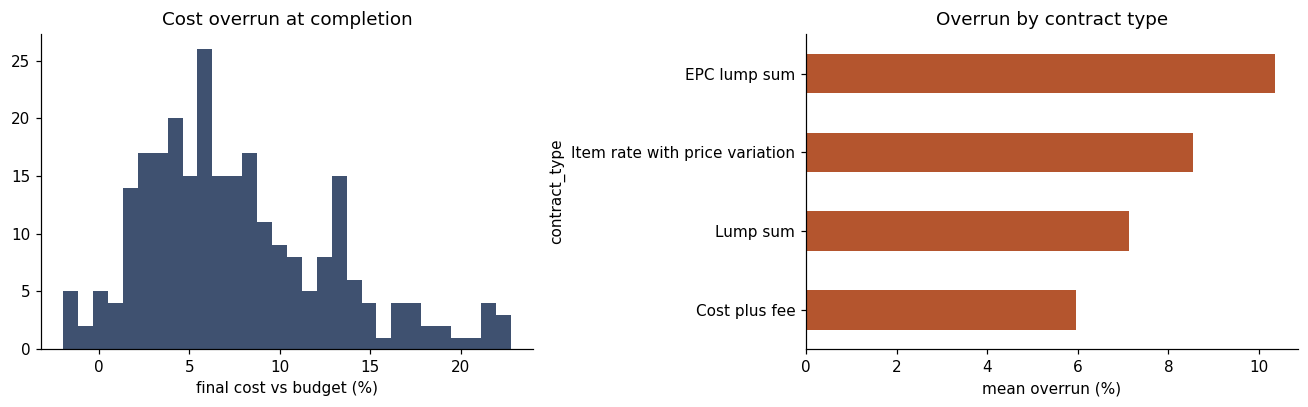

,projects,overrun_pct,margin_fade_pts
project_type,,,
Metro Viaduct,20,13.3,12.0
Data Centre,21,10.8,9.7
Hospital Campus,26,8.3,7.4
Highway Package,26,8.2,7.3
Water Treatment Plant,27,7.8,6.9
Residential Towers,29,7.3,6.5
Industrial Plant,21,7.3,6.5
Commercial Complex,32,6.1,5.4
IT Park,28,5.4,4.8


In [3]:
done = reg[reg.status == 'Completed'].copy()
done['overrun_pct'] = (done.final_cost / done.bac - 1) * 100
done['final_margin_pct'] = (done.contract_value - done.final_cost) / done.contract_value * 100
done['margin_fade_pts'] = done.tender_margin_pct - done.final_margin_pct
print(f"{len(done)} completed projects: tender margin {done.tender_margin_pct.mean():.1f}% on average, final margin {done.final_margin_pct.mean():.1f}%; "
      f"{(done.final_margin_pct < 0).mean():.0%} ended in a loss")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(done.overrun_pct, bins=30, color='#3f5170'); ax[0].set_xlabel('final cost vs budget (%)'); ax[0].set_title('Cost overrun at completion')
done.groupby('contract_type').overrun_pct.mean().sort_values().plot.barh(ax=ax[1], color='#b4552e'); ax[1].set_xlabel('mean overrun (%)'); ax[1].set_title('Overrun by contract type')
plt.tight_layout(); plt.show()
done.groupby('project_type').agg(projects=('project_id', 'size'), overrun_pct=('overrun_pct', 'mean'), margin_fade_pts=('margin_fade_pts', 'mean')).round(1).sort_values('overrun_pct', ascending=False)

## 3. Why the CPI formula under-forecasts

In [4]:
S = snapshots(reg, F, idx)
S['stage'] = pd.cut(S.pct_complete, [0, .3, .6, .99], labels=['early (<30%)', 'mid (30-60%)', 'late (>60%)'])
h = S[S.final_cost.notna()]
bias = h.groupby('stage').apply(lambda g: pd.Series({'CPI formula EAC vs final cost (%)': ((g.eac_cpi / g.final_cost - 1) * 100).mean(),
                                                      'share of forecasts below final cost': (g.eac_cpi < g.final_cost).mean()}))
print(bias.round(2).to_string())

              CPI formula EAC vs final cost (%)  share of forecasts below final cost
stage                                                                               
early (<30%)                               2.11                                 0.37
mid (30-60%)                              -3.32                                 0.86
late (>60%)                               -3.18                                 0.99


Early in a job the CPI formula is erratic: site set-up and overheads are front-loaded, so CPI looks poor and the forecast is too high. From mid-stage onwards it flips and becomes **too optimistic**: most mid-stage and almost all late-stage CPI forecasts are below the final cost. Three things in real projects push cost up *after* CPI is measured:
- **Site overheads burn with time, not progress.** When a job runs late, prefabs, staff and security keep costing money every month.
- **Material price movement** hits lump-sum contracts more than item-rate contracts with price variation clauses.
- **Late subcontractor claims and rework** arrive near completion.

A model that sees schedule slippage, overhead burn, contract type and category-level CPIs can learn these patterns from completed projects.

## 4. Monthly snapshots and features
Each row is one project at one month-end, from 5% to 99% complete, using only cost reports up to that month. The target is **final cost / budget**, modelled in log form. The features are:
- **Progress:** % complete, time elapsed vs plan, months over plan, SPI.
- **Cost performance:** cumulative CPI, last-3-month CPI and its trend, and CPI for labour, material, equipment and subcontract.
- **Overheads:** share of the overhead budget spent vs progress.
- **Market:** material price index change since tender.
- **Known at award:** project type, client, contract type, design maturity, complexity, PM experience, duration and size.

In [5]:
TYPEC = [c for c in S if c.startswith('type_')]
FEATS = DYN + STATIC + TYPEC
LABELS = {'pct_complete': '% complete', 'time_ratio': 'Time elapsed vs plan', 'months_over_plan': 'Months over planned duration', 'cpi': 'CPI (cumulative)', 'cpi_3m': 'CPI last 3 months',
          'cpi_trend': 'CPI trend (3-month vs cumulative)', 'spi': 'SPI', 'spi_time': 'Progress vs planned progress', 'cpi_labor': 'Labour CPI', 'cpi_material': 'Material CPI',
          'cpi_equipment': 'Equipment CPI', 'cpi_subcontract': 'Subcontract CPI', 'overhead_burn': 'Overhead budget spent', 'overhead_vs_progress': 'Overhead spent ahead of progress',
          'mat_index_change': 'Material index change since tender', 'burn_last3': 'Spend last 3 months (x budget)', 'ev_last3': 'Progress last 3 months', 'design_maturity_pct': 'Design maturity at award',
          'complexity': 'Complexity', 'pm_experience_years': 'PM experience', 'planned_months': 'Planned duration', 'log_bac': 'Budget size (log)', 'is_gov': 'Government client',
          'ct_item': 'Contract: item rate + price variation', 'ct_epc': 'Contract: EPC lump sum', 'ct_lump': 'Contract: lump sum', 'ct_cost': 'Contract: cost plus fee'}
LABELS.update({c: 'Type: ' + c[5:].replace('_', ' ').title() for c in TYPEC})
print(len(S), 'snapshots from', S.project_id.nunique(), 'projects |', len(FEATS), 'features')
S.loc[S.project_id == 'PRJ001', ['month', 'pct_complete', 'cpi', 'cpi_3m', 'spi', 'overhead_vs_progress', 'eac_cpi', 'final_cost']].head(6).round(3)

4891 snapshots from 269 projects | 37 features


,month,pct_complete,cpi,cpi_3m,spi,overhead_vs_progress,eac_cpi,final_cost
0,2025-06-01,0.053,0.871,0.871,0.676,0.107,6.026192e+09,NaN
1,2025-07-01,0.083,0.847,0.847,0.510,0.147,6.195733e+09,NaN
2,2025-08-01,0.134,0.904,0.940,0.502,0.170,5.806819e+09,NaN
3,2025-09-01,0.197,0.927,0.950,0.515,0.183,5.660359e+09,NaN
4,2025-10-01,0.282,0.935,0.978,0.560,0.175,5.612999e+09,NaN
5,2025-11-01,0.346,0.939,0.963,0.556,0.189,5.590736e+09,NaN


## 5. Train / validation / test split by time

In [6]:
hist = S.portfolio != 'Current portfolio'
S['split'] = np.select([hist & (S.planned_start < '2021-07-01'), hist, S.final_cost.notna()], ['train', 'valid', 'test'], 'live')
tr, va, te, lv = [(S.split == s).values for s in ('train', 'valid', 'test', 'live')]
y = np.log(S.y_ratio)
S.groupby('split', sort=False).agg(projects=('project_id', 'nunique'), snapshots=('project_id', 'size'), first_start=('planned_start', 'min'), last_start=('planned_start', 'max'))

,projects,snapshots,first_start,last_start
split,,,,
live,9,153,2024-10-06,2025-06-11
test,21,249,2024-11-02,2025-06-25
train,184,3536,2016-01-24,2021-06-27
valid,55,953,2021-07-10,2023-08-04


- **Train:** historical projects that started before July 2021.
- **Validation:** historical projects that started later. Used to tune the models and calibrate the ranges.
- **Test:** the 21 current-portfolio projects that have finished, so their true final cost is known. Every monthly forecast they had is scored.
- **Live:** the 9 current projects still in progress. Their outcome is not known yet.

A project never appears in two sets.

## 6. Baselines: earned-value formulas

In [7]:
def ape(pred, m): return (np.abs(pred[m] - S.final_cost[m]) / S.final_cost[m] * 100)
def score(pred, m):
    e = ape(pred, m); b = ((pred[m] / S.final_cost[m] - 1) * 100)
    return {'MAPE %': e.mean(), 'bias %': b.mean(), **{f'MAPE {s}': e[S.stage[m] == s].mean() for s in S.stage.cat.categories}}
PRED = {'EVM: remaining at budget': S.eac_budget, 'EVM: CPI formula': S.eac_cpi, 'EVM: CPI x SPI formula': S.eac_cpi_spi}
pd.DataFrame({n: score(p, te) for n, p in PRED.items()}).T.round(2)

,MAPE %,bias %,MAPE early (<30%),MAPE mid (30-60%),MAPE late (>60%)
EVM: remaining at budget,3.51,-3.48,4.59,3.92,2.70
EVM: CPI formula,3.01,-0.76,4.61,2.78,2.24
EVM: CPI x SPI formula,15.85,11.91,40.18,15.09,2.77


## 7. Models

In [8]:
def fit_pick(name, cands):
    best = None
    for m in cands:
        m.fit(S.loc[tr, FEATS], y[tr]); p = S.bac * np.exp(m.predict(S[FEATS])); e = ape(p, va).mean()
        if best is None or e < best[1]: best = (m, e)
    PRED[name] = pd.Series(S.bac * np.exp(best[0].predict(S[FEATS])), index=S.index); print(f'{name:22s} validation MAPE {best[1]:.2f}% ({len(cands)} settings)'); return best[0]
imp_ = lambda: SimpleImputer(strategy='median')
ridge = fit_pick('Ridge regression', [make_pipeline(imp_(), StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30)))])
rf = fit_pick('Random Forest', [make_pipeline(imp_(), RandomForestRegressor(n_estimators=500, min_samples_leaf=l, max_features=f, n_jobs=4, random_state=7)) for l in (3, 8) for f in (.3, .6)])
XGBP = dict(learning_rate=.03, subsample=.8, colsample_bytree=.7, min_child_weight=5, n_jobs=4, random_state=7)
xg = fit_pick('XGBoost', [xgb.XGBRegressor(n_estimators=n, max_depth=d, **XGBP) for n in (300, 600) for d in (2, 3, 4)])
mlp = fit_pick('Neural Network (MLP)', [make_pipeline(imp_(), StandardScaler(), MLPRegressor(hidden_layer_sizes=h, alpha=a, max_iter=3000, early_stopping=True, random_state=7)) for h in ((32,), (64, 32)) for a in (1e-3, 1e-2)])
print('chosen XGBoost:', {k: xg.get_params()[k] for k in ('n_estimators', 'max_depth')})

Ridge regression       validation MAPE 2.38% (1 settings)


Random Forest          validation MAPE 2.61% (4 settings)


XGBoost                validation MAPE 2.59% (6 settings)


Neural Network (MLP)   validation MAPE 3.62% (4 settings)
chosen XGBoost: {'n_estimators': 300, 'max_depth': 2}


**LSTM.** The models above see one month's summary. An LSTM reads the whole monthly history of a project, up to the snapshot, as a sequence, and learns its own trend features. The static facts known at award are joined after the recurrent layer.

In [9]:
SEQ = DYN; L = 36
imp_seq = SimpleImputer(strategy='median').fit(S.loc[tr, SEQ]); sc_seq = StandardScaler().fit(imp_seq.transform(S.loc[tr, SEQ]))
imp_st = SimpleImputer(strategy='median').fit(S.loc[tr, STATIC + TYPEC]); sc_st = StandardScaler().fit(imp_st.transform(S.loc[tr, STATIC + TYPEC]))
Zs = sc_seq.transform(imp_seq.transform(S[SEQ])); Zt = sc_st.transform(imp_st.transform(S[STATIC + TYPEC]))
Xseq = np.zeros((len(S), L, len(SEQ)), 'float32')
for pid, g in S.groupby('project_id'):
    ix = g.sort_values('month').index.values
    for k, i in enumerate(ix):
        h_ = Zs[ix[max(0, k - L + 1):k + 1]]; Xseq[i, L - len(h_):] = h_
inp_s = tf.keras.Input((L, len(SEQ))); inp_t = tf.keras.Input((Zt.shape[1],))
hdd = tf.keras.layers.Masking(0.)(inp_s); hdd = tf.keras.layers.LSTM(32)(hdd)
hdd = tf.keras.layers.Concatenate()([hdd, inp_t]); hdd = tf.keras.layers.Dense(32, activation='relu')(hdd); hdd = tf.keras.layers.Dropout(.2)(hdd)
lstm = tf.keras.Model([inp_s, inp_t], tf.keras.layers.Dense(1)(hdd)); lstm.compile(tf.keras.optimizers.Adam(2e-3), 'mae')
hist_ = lstm.fit([Xseq[tr], Zt[tr]], y[tr].values, validation_data=([Xseq[va], Zt[va]], y[va].values), epochs=80, batch_size=64, verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
PRED['LSTM (sequence model)'] = pd.Series(S.bac * np.exp(lstm.predict([Xseq, Zt], verbose=0)[:, 0]), index=S.index)
print(f"LSTM stopped after {len(hist_.history['loss'])} epochs, validation MAPE {ape(PRED['LSTM (sequence model)'], va).mean():.2f}%")

LSTM stopped after 32 epochs, validation MAPE 3.03%


## 8. Accuracy on the test projects, by stage of completion

In [10]:
res = pd.DataFrame({n: score(p, te) for n, p in PRED.items()}).T.sort_values('MAPE %')
res.round(2)

,MAPE %,bias %,MAPE early (<30%),MAPE mid (30-60%),MAPE late (>60%)
XGBoost,2.30,0.65,2.80,2.39,1.98
Random Forest,2.35,1.18,2.97,2.37,1.99
Ridge regression,2.48,0.54,3.34,2.59,1.95
EVM: CPI formula,3.01,-0.76,4.61,2.78,2.24
Neural Network (MLP),3.22,1.17,3.34,3.37,3.08
LSTM (sequence model),3.43,1.43,3.74,3.16,3.39
EVM: remaining at budget,3.51,-3.48,4.59,3.92,2.70
EVM: CPI x SPI formula,15.85,11.91,40.18,15.09,2.77


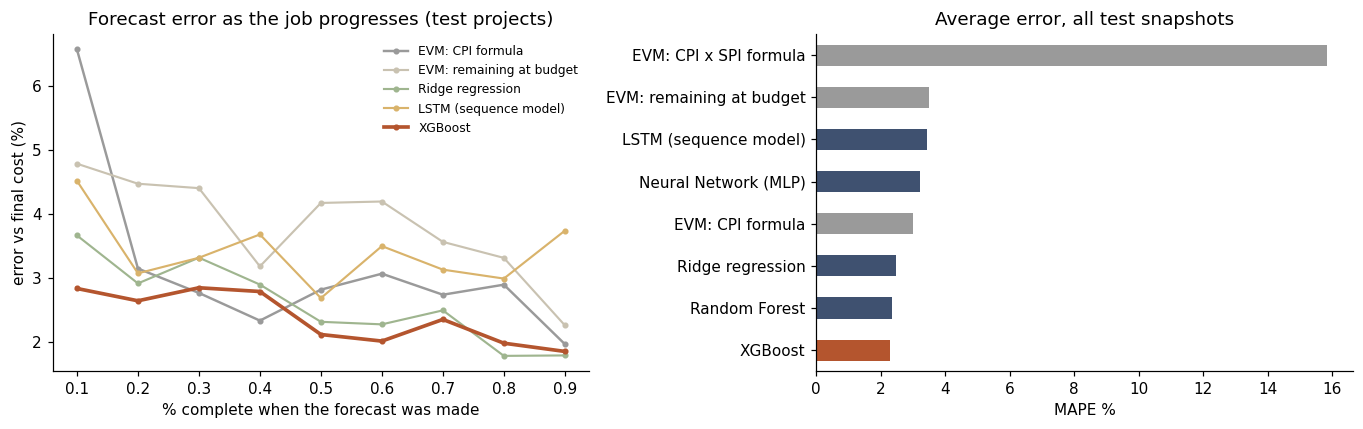

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
bins = np.arange(.05, 1.0, .1); cen = bins[:-1] + .05
for n, c, lw in [('EVM: CPI formula', '#9a9a9a', 1.6), ('EVM: remaining at budget', '#c9c2b1', 1.4), ('Ridge regression', '#9fb58f', 1.4), ('LSTM (sequence model)', '#d9b36b', 1.4), ('XGBoost', '#b4552e', 2.4)]:
    e = ape(PRED[n], te); g = e.groupby(pd.cut(S.pct_complete[te], bins)).mean(); ax[0].plot(cen, g.values, color=c, lw=lw, label=n, marker='o', ms=3)
ax[0].set_xlabel('% complete when the forecast was made'); ax[0].set_ylabel('error vs final cost (%)'); ax[0].legend(frameon=False, fontsize=8); ax[0].set_title('Forecast error as the job progresses (test projects)')
res['MAPE %'].sort_values().plot.barh(ax=ax[1], color=['#b4552e' if i == 'XGBoost' else '#9a9a9a' if i.startswith('EVM') else '#3f5170' for i in res['MAPE %'].sort_values().index])
ax[1].set_xlabel('MAPE %'); ax[1].set_title('Average error, all test snapshots'); plt.tight_layout(); plt.show()

In [12]:
# the question a commercial manager asks: how wrong is the forecast margin, in percentage points of contract value?
T = S[te].copy()
for n in ('EVM: CPI formula', 'XGBoost'): T['margin_err_' + n] = (PRED[n][te] - T.final_cost).abs() / T.contract_value * 100
at50 = T[(T.pct_complete >= .45) & (T.pct_complete <= .55)].groupby('project_id')[[c for c in T if c.startswith('margin_err_')]].mean()
print(f'Forecast margin error at about 50% complete (percentage points, mean of {len(at50)} test projects):'); print(at50.mean().round(2).to_string())
print('Projects where XGBoost was closer than the CPI formula at ~50%:', int((at50['margin_err_XGBoost'] < at50['margin_err_EVM: CPI formula']).sum()), 'of', len(at50))

Forecast margin error at about 50% complete (percentage points, mean of 20 test projects):
margin_err_EVM: CPI formula    2.78
margin_err_XGBoost             1.93
Projects where XGBoost was closer than the CPI formula at ~50%: 14 of 20


## 9. Forecast ranges (P10–P90)
A single number is not enough for a cost report. Two extra XGBoost models learn the 10th and 90th percentiles, and the band is widened on the validation projects (conformal calibration) aiming for 80% coverage.

In [13]:
xp = {k: v for k, v in xg.get_params().items() if k in ('n_estimators', 'max_depth')}
q10 = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=.1, **xp, **XGBP).fit(S.loc[tr, FEATS], y[tr])
q90 = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=.9, **xp, **XGBP).fit(S.loc[tr, FEATS], y[tr])
lo_, hi_ = q10.predict(S[FEATS]), q90.predict(S[FEATS])
s_val = np.maximum(lo_[va] - y[va], y[va] - hi_[va]); ADJ = float(np.quantile(s_val, .8))
LO, HI = S.bac * np.exp(lo_ - ADJ), S.bac * np.exp(hi_ + ADJ)
cov = ((S.final_cost >= LO) & (S.final_cost <= HI))[te].mean()
print(f'Conformal adjustment {ADJ:+.4f} (log) | test coverage of the P10-P90 band: {cov:.1%} | median band width: {((HI - LO) / S.bac)[te].median():.1%} of budget')

Conformal adjustment +0.0079 (log) | test coverage of the P10-P90 band: 76.3% | median band width: 7.0% of budget


## 10. Explain the model (SHAP)

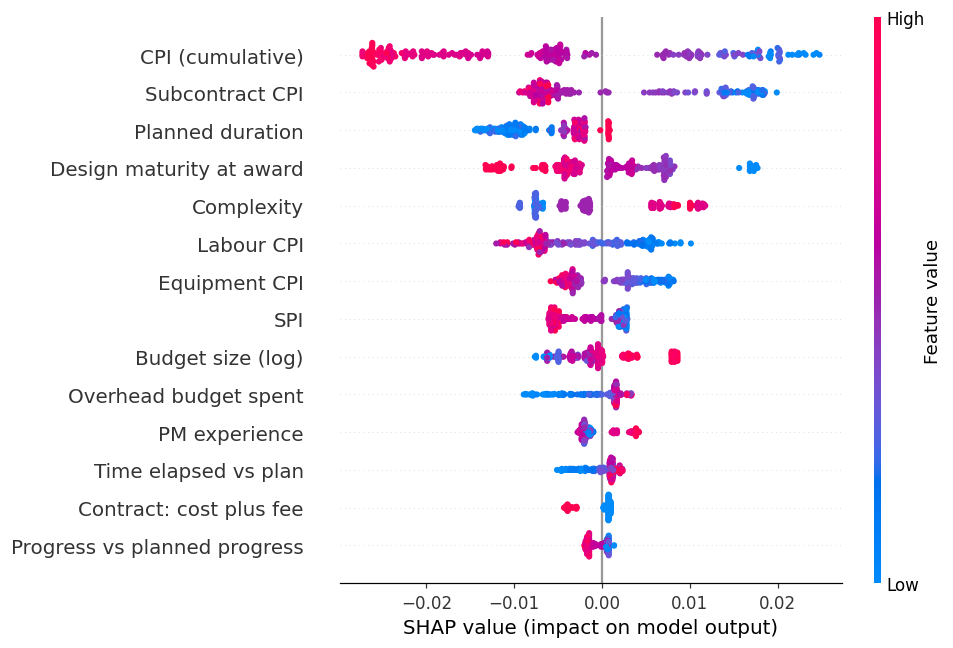

CPI (cumulative)            0.0154
Subcontract CPI             0.0091
Planned duration            0.0074
Design maturity at award    0.0061
Complexity                  0.0060
Labour CPI                  0.0057
Equipment CPI               0.0041
SPI                         0.0035
Budget size (log)           0.0032
Overhead budget spent       0.0024
dtype: float32

In [14]:
ex = shap.TreeExplainer(xg); sv = ex.shap_values(S.loc[te, FEATS])
shap.summary_plot(sv, S.loc[te, FEATS].rename(columns=LABELS), max_display=14, show=False, plot_size=(9, 6)); plt.tight_layout(); plt.show()
imp = pd.Series(np.abs(sv).mean(0), index=FEATS).sort_values(ascending=False)
imp.head(10).rename(LABELS).round(4)

The model starts from CPI, like the formula, then corrects it: slipping schedules and overheads spent ahead of progress push the forecast up. So do weak subcontract and material CPIs, and lump-sum exposure to material prices. Item-rate contracts with price variation, and cost-plus contracts, pull it down.

## 11. Next-quarter spend
Finance also needs the next three months of cost for cash-flow planning. Four methods are compared on the test projects:
- **Naive:** the last 3 months repeat.
- **Plan × CPI:** baseline planned value for the next 3 months ÷ CPI.
- **Holt's exponential smoothing:** a classic time-series model fitted to each project's own monthly cost.
- **XGBoost:** one global model trained on all historical projects, with lags, plan and progress features.

In [15]:
S['pv_next3_r'] = S.pv_next3 / S.bac; S['remaining_r'] = 1 - S.pct_complete
Q = S[S.next3_actual.notna()].copy()
Q['f_naive'] = Q.burn_last3 * Q.bac
Q['f_plan_cpi'] = Q.pv_next3 / Q.cpi
def holt(h):
    h = np.asarray(h, float)
    if len(h) < 4: return 3 * h[-3:].mean()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            return float(np.clip(ExponentialSmoothing(h, trend='add', damped_trend=True, initialization_method='estimated').fit(optimized=True).forecast(3).sum(), 0, None))
    except Exception: return 3 * h[-3:].mean()
Q['f_holt'] = [holt(h) for h in Q.hist_monthly]
QF = ['pv_next3_r', 'remaining_r', 'monsoon_next3'] + FEATS
qtr, qva, qte = [(Q.split == s).values for s in ('train', 'valid', 'test')]
qx = xgb.XGBRegressor(n_estimators=500, max_depth=3, **XGBP).fit(Q.loc[qtr, QF], Q.next3_actual[qtr] / Q.bac[qtr])
Q['f_xgb'] = qx.predict(Q[QF]) * Q.bac
S['f_xgb_q'] = qx.predict(S[QF]) * S.bac   # also for the latest month of live projects, whose next quarter hasn't happened yet
wape = lambda f, m: (np.abs(Q[f][m] - Q.next3_actual[m]).sum() / Q.next3_actual[m].sum() * 100)
qres = pd.DataFrame({n: {'WAPE validation %': wape(f, qva), 'WAPE test %': wape(f, qte)} for n, f in [('Naive (last 3 months)', 'f_naive'), ('Plan x CPI', 'f_plan_cpi'),
                     ("Holt's exponential smoothing", 'f_holt'), ('XGBoost (global)', 'f_xgb')]}).T.sort_values('WAPE test %')
qres.round(2)

,WAPE validation %,WAPE test %
XGBoost (global),11.93,13.66
Plan x CPI,38.60,36.29
Naive (last 3 months),32.86,40.12
Holt's exponential smoothing,42.21,54.75


WAPE = total absolute error ÷ total actual spend. Monthly cost reports are noisy, because accruals are booked and reversed, so no method is precise month by month. The global XGBoost model does best because it combines the plan, the recent burn rate and how far along the job is. Holt's method only sees one project's own short history.

## 12. Live forecast for the projects still in progress

In [16]:
L_ = S[lv].sort_values('month').groupby('project_id').tail(1).copy()
L_['eac_xgb'] = PRED['XGBoost'][L_.index]; L_['p10'] = LO[L_.index]; L_['p90'] = HI[L_.index]
L_['margin_forecast_pct'] = (L_.contract_value - L_.eac_xgb) / L_.contract_value * 100
L_['margin_cpi_formula_pct'] = (L_.contract_value - L_.eac_cpi) / L_.contract_value * 100
L_['margin_range'] = [f'{(c - h) / c * 100:.1f}% to {(c - l) / c * 100:.1f}%' for c, l, h in zip(L_.contract_value, L_.p10, L_.p90)]
lq = Q[Q.split == 'live'] if 'live' in Q.split.values else None
live_tbl = L_[['project_id', 'project_name', 'pct_complete', 'cpi', 'spi', 'tender_margin_pct', 'margin_cpi_formula_pct', 'margin_forecast_pct', 'margin_range']].assign(
    eac_cr=cr(L_.eac_xgb), pct_complete=L_.pct_complete * 100).round(2).sort_values('margin_forecast_pct')
live_tbl

,project_id,project_name,pct_complete,cpi,spi,tender_margin_pct,margin_cpi_formula_pct,margin_forecast_pct,margin_range,eac_cr
401,PRJ030,Surat Water Treatment Plant 3,98.26,0.92,0.98,7.2,-1.31,-3.86,-6.1% to -0.2%,392.07
147,PRJ011,Jaipur Metro Viaduct 2,94.40,0.92,0.94,12.2,4.91,0.49,-2.4% to 4.2%,399.72
313,PRJ023,Chennai Residential Towers 3,97.08,0.97,0.97,5.0,2.15,1.09,-1.7% to 1.8%,253.41
352,PRJ026,Jaipur Industrial Plant 3,95.64,0.96,0.96,10.3,6.91,2.48,0.3% to 7.3%,495.29
63,PRJ005,Gurugram Hospital Campus 1,94.93,0.98,0.95,6.2,4.28,3.27,0.4% to 4.2%,308.18
236,PRJ017,Pune Data Centre 2,94.50,0.96,0.95,15.0,11.88,7.04,5.4% to 11.1%,588.24
13,PRJ001,Mumbai Metro Viaduct 1,98.74,0.97,0.99,13.5,10.88,7.73,7.3% to 10.6%,559.98
94,PRJ007,Hyderabad Data Centre 1,98.46,0.97,0.98,13.0,10.35,7.88,5.9% to 10.1%,500.95
216,PRJ016,Mumbai Industrial Plant 2,98.36,0.98,0.98,11.9,10.02,8.86,5.5% to 9.4%,475.58


In [17]:
print(f"ML forecast margin below the CPI-formula margin on {int((L_.margin_forecast_pct < L_.margin_cpi_formula_pct).sum())} of {len(L_)} live projects")

ML forecast margin below the CPI-formula margin on 9 of 9 live projects


Where the ML forecast margin sits below what the CPI formula implies, that gap is the difference between a comfortable cost report and a margin conversation that needs to happen now.

## 13. Export for the web app

In [18]:
def dump(m): return [json.loads(t_) for t_ in m.get_booster().get_dump(dump_format='json')]
def base_score(m): return float(json.loads(m.get_booster().save_config())['learner']['learner_model_param']['base_score'].strip('[]'))
f32 = lambda v: None if pd.isna(v) else float(np.float32(v))
PS = S[S.portfolio == 'Current portfolio'].sort_values(['project_id', 'month'])
monthly = F[F.project_id.isin(PS.project_id.unique())].groupby(['project_id', 'period_month'])[['planned_value', 'earned_value', 'actual_cost']].sum().reset_index()
proj = {}
for pid, g in monthly.groupby('project_id'):
    r = reg.set_index('project_id').loc[pid]; s = PS[PS.project_id == pid]
    q = Q[Q.project_id == pid].set_index('month')
    proj[pid] = {'name': r.project_name, 'type': r.project_type, 'city': r.city, 'client': r.client_type, 'contract': r.contract_type, 'cv': float(r.contract_value), 'bac': float(r.bac),
                 'tender_margin': float(r.tender_margin_pct), 'status': r.status, 'final': None if pd.isna(r.final_cost) else float(r.final_cost), 'planned_months': int(r.planned_months),
                 'start': str(r.planned_start.date()), 'finish': str(r.planned_finish.date()),
                 'm': g.period_month.dt.strftime('%Y-%m').tolist(), 'pv': g.planned_value.round(0).tolist(), 'ev': g.earned_value.round(0).tolist(), 'ac': g.actual_cost.round(0).tolist(),
                 'snaps': [{'month': mo.strftime('%Y-%m'), 'pct': round(float(pc), 4), 'cpi': round(float(c), 4), 'spi': None if pd.isna(sp) else round(float(sp), 4), 'x': [f32(v) for v in xr],
                            'eac': {n: float(PRED[n][i]) for n in PRED}, 'p10': float(LO[i]), 'p90': float(HI[i]),
                            'q': {'xgb': float(S.f_xgb_q[i]), **({} if mo not in q.index else {'actual': float(q.loc[mo, 'next3_actual']), 'holt': float(q.loc[mo, 'f_holt']), 'plan': float(q.loc[mo, 'f_plan_cpi']), 'naive': float(q.loc[mo, 'f_naive'])})}}
                           for i, mo, pc, c, sp, xr in zip(s.index, s.month, s.pct_complete, s.cpi, s.spi, s[FEATS].values)]}
export = {'features': FEATS, 'labels': LABELS, 'data_date': '2026-08',
          'xgb': {'base_score': base_score(xg), 'trees': dump(xg)}, 'q10': {'base_score': base_score(q10), 'trees': dump(q10)}, 'q90': {'base_score': base_score(q90), 'trees': dump(q90)}, 'adj': ADJ,
          'results': res.reset_index().rename(columns={'index': 'model'}).to_dict(orient='records'), 'qres': qres.reset_index().rename(columns={'index': 'model'}).to_dict(orient='records'),
          'coverage': float(cov), 'importance': imp.head(10).round(5).to_dict(), 'at50': at50.mean().round(3).to_dict(),
          'fade': {'n': int(len(done)), 'tender': float(done.tender_margin_pct.mean()), 'final': float(done.final_margin_pct.mean()), 'loss_share': float((done.final_margin_pct < 0).mean())},
          'bias': bias.reset_index().astype({'stage': str}).to_dict(orient='records'), 'projects': proj,
          'n_hist': int((reg.portfolio != 'Current portfolio').sum()), 'n_snap_train': int(tr.sum())}
with open('../model/forecast_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'), allow_nan=False)
print('Exported', sum(len(export[k]['trees']) for k in ('xgb', 'q10', 'q90')), 'trees |', f"{os.path.getsize('../model/forecast_export.json') / 1e6:.2f} MB")

Exported 900 trees | 0.84 MB


## Summary
- **Data:** 239 completed projects and the 30 current portfolio projects, with monthly cost reports by category (planned value, earned value, actual cost) and a material price index. Completed projects lost about half their tender margin on average (section 2).
- **Finding:** the standard CPI formula systematically under-forecasts final cost, most of all early in a job, because overhead prolongation, material price movement and late claims arrive after CPI is measured.
- **Result:** trained only on older projects and tested on the 21 finished portfolio projects, XGBoost has the lowest error: 2.3% vs 3.0% for the CPI formula overall, and 2.8% vs 4.6% in the early stage, when a forecast matters most (section 8). Random Forest and Ridge are close behind. The LSTM sits behind the tree models: about 240 projects is little history for a sequence model, so simpler models trained on well-designed features win here. XGBoost also gives a calibrated P10–P90 range that held the final cost about three times in four on the test projects (section 9) and explainable drivers (section 10).
- **Cash flow:** for next-quarter spend, one global XGBoost model has about a third of the error of the naive, plan × CPI and Holt's smoothing methods (section 11).
- **Honest limits:** the data is synthetic, with a known cost process. The test set is 21 projects, so figures will move with more projects. Real use needs the company's own completed-project history and a retrain each quarter.